In [47]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


### IMPORT LIBRARIES

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from matplotlib import pyplot as plt
import time
import torchvision.models as models
import optuna

### LOAD DATA

In [49]:
# TRAIN transforms
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# VALIDATION transforms
val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])
# TEST transforms
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [50]:
full_dataset = datasets.ImageFolder(root="IMAGE dATASET")

In [51]:
train_size = int(0.80 * len(full_dataset))
val_size = int(0.10 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_set, val_set, test_set = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training:", len(train_set))
print("Validation:", len(val_set))
print("Testing:", len(test_set))

Training: 35296
Validation: 4412
Testing: 4412


In [52]:
train_set.dataset.transform = train_transforms
val_set.dataset.transform   = val_transforms
test_set.dataset.transform  = test_transforms

In [53]:
full_dataset.classes

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Banana_Cordana',
 'Banana_Healthy',
 'Banana_Pestalotiopsis',
 'Banana_Sigatoka',
 'Blackgarm_Anthracnose',
 'Blackgarm_Healthy',
 'Blackgarm_Leaf Crinckle',
 'Blackgarm_Powdery Mildew',
 'Blackgarm_Yellow Mosaic',
 'Maize_Cercospora_leaf_spot Gray_leaf_spot',
 'Maize_Common_rust_',
 'Maize_Healthy',
 'Maize_aphid',
 'Maize_curvularia_leaf_spot',
 'Maize_fall_armyworm',
 'Maize_maydis_leaf_blight',
 'Maize_sorghum_downy_mildew',
 'Maize_turcicum_leaf_blight',
 'Mango_Anthracnose',
 'Mango_Bacterial Canker',
 'Mango_Cutting Weevil',
 'Mango_Die Back',
 'Mango_Gall Midge',
 'Mango_Healthy',
 'Mango_Powdery Mildew',
 'Mango_Sooty Mould',
 'Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Rice_Bacterial_leaf_blight',
 'Rice_Brown_spot',
 'Rice_False_smut',
 'Rice_Healthy',
 'Rice_Leaf_folder',
 'Rice_Rice_skipper

In [54]:
num_classes = len(full_dataset.classes)
num_classes

54

In [55]:
print(len(train_set))
print(len(val_set))
print(len(test_set))

35296
4412
4412


### Dataloader creation

In [56]:
train_loader = DataLoader(
    train_set,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_set,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_set,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

In [57]:
for images, labels in train_loader:
  print(images.shape)
  print(labels.shape)
  break

torch.Size([64, 3, 224, 224])
torch.Size([64])


In [58]:
images[0].shape

torch.Size([3, 224, 224])

In [59]:
labels[2]

tensor(23)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7347276..1.8382572].


tensor(23)


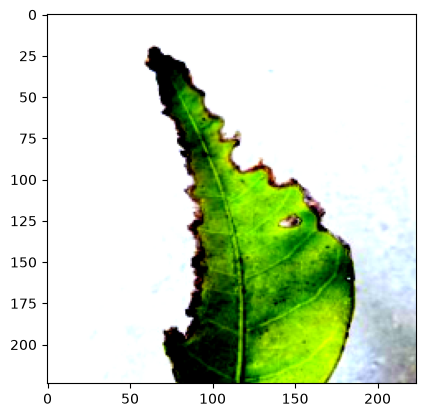

In [60]:
plt.imshow(images[2].permute(1,2,0))
plt.show
print(labels[2])

### Training loop

In [61]:
def train_model(model, criterion, optimizer, epochs):

    start = time.time()

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):

        ###########################
        # TRAINING
        ###########################

        model.train()
        running_loss = 0.0

        for batch_num, (images, labels) in enumerate(train_loader):

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            train_loss = criterion(outputs, labels)

            train_loss.backward()
            optimizer.step()

            if (batch_num + 1) % 70 == 0:
                print(
                    f'Batch : {batch_num+1}, '
                    f'Epoch : {epoch+1}, '
                    f'Loss = {train_loss.item():0.2f}'
                )

            running_loss += train_loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        train_losses.append(epoch_train_loss)

        print(
            f'Epoch [{epoch+1}/{epochs}] | '
            f'Train Loss: {epoch_train_loss:.4f}'
        )

        ###########################
        # VALIDATION
        ###########################

        model.eval()

        val_running_loss = 0.0
        correct = 0
        total = 0

        all_labels = []
        all_predictions = []

        with torch.no_grad():

            for images, labels in val_loader:

                images, labels = images.to(device), labels.to(device)

                outputs = model(images)

                val_loss = criterion(outputs, labels)

                val_running_loss += val_loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

        epoch_val_loss = val_running_loss / len(val_loader.dataset)

        accuracy = 100 * correct / total

        val_losses.append(epoch_val_loss)
        val_accuracies.append(accuracy)

        print(
            f'Validation Loss: {epoch_val_loss:.4f} | '
            f'Validation Accuracy: {accuracy:.2f}%'
        )

    end = time.time()

    print(f'Execution time: {end-start:.2f} seconds')

    return (
        train_losses,
        val_losses,
        val_accuracies,
        all_labels,
        all_predictions
    )

### Model 1 : CNN


In [62]:
class PlantDisease_img_classifier (nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.network = nn.Sequential(

        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),  #(3, 224, 224) -> (16, 224, 224)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2), #(16, 112, 112)

        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), #(16, 112, 112) -> (32, 112, 112)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2), #(32, 56, 56)

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),  #(32, 56, 56) -> (64, 56, 56)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2), #(64, 28, 28)

        nn.Flatten(),
        nn.Linear(64* 28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes)
    )


  def forward(self, x):
    x = self.network(x)
    return x


In [63]:
model = PlantDisease_img_classifier(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [64]:
cnn_results = train_model(model, criterion, optimizer, epochs=10)
cnn_train_loss, cnn_val_loss, cnn_val_acc, cnn_labels, cnn_predictions = cnn_results

Batch : 70, Epoch : 1, Loss = 1.82
Batch : 140, Epoch : 1, Loss = 1.08
Batch : 210, Epoch : 1, Loss = 0.96
Batch : 280, Epoch : 1, Loss = 0.98
Batch : 350, Epoch : 1, Loss = 0.65
Batch : 420, Epoch : 1, Loss = 0.56
Batch : 490, Epoch : 1, Loss = 0.49
Epoch [1/10] | Train Loss: 1.1175
Validation Loss: 0.5890 | Validation Accuracy: 81.05%
Batch : 70, Epoch : 2, Loss = 0.58
Batch : 140, Epoch : 2, Loss = 0.48
Batch : 210, Epoch : 2, Loss = 0.57
Batch : 280, Epoch : 2, Loss = 0.40
Batch : 350, Epoch : 2, Loss = 0.45
Batch : 420, Epoch : 2, Loss = 0.20
Batch : 490, Epoch : 2, Loss = 0.49
Epoch [2/10] | Train Loss: 0.4230
Validation Loss: 0.3917 | Validation Accuracy: 88.10%
Batch : 70, Epoch : 3, Loss = 0.16
Batch : 140, Epoch : 3, Loss = 0.21
Batch : 210, Epoch : 3, Loss = 0.08
Batch : 280, Epoch : 3, Loss = 0.44
Batch : 350, Epoch : 3, Loss = 0.19
Batch : 420, Epoch : 3, Loss = 0.16
Batch : 490, Epoch : 3, Loss = 0.27
Epoch [3/10] | Train Loss: 0.2569
Validation Loss: 0.3917 | Validation 

### Model 2 : CNN_With_Regularization


In [65]:
class PlantDisease_with_Regularization (nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.network = nn.Sequential(

        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),  #(3, 224, 224) -> (16, 224, 224)
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2), #(16, 112, 112)

        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), #(16, 112, 112) -> (32, 112, 112)
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2), #(32, 56, 56)

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),  #(32, 56, 56) -> (64, 56, 56)
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2), #(64, 28, 28)

        nn.Flatten(),
        nn.Linear(64* 28*28, 1000),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(1000, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)

    )


  def forward(self, x):
    x = self.network(x)
    return x


In [66]:
model_with_regularization = PlantDisease_with_Regularization(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_with_regularization.parameters(), lr=0.001, weight_decay = 1e-4)

In [67]:
cnn_regularized_results  = train_model(model_with_regularization, criterion, optimizer, epochs=10)
cnn_regularized_train_loss, cnn_regularized_val_loss, cnn_regularized_val_acc, cnn_regularized_labels, cnn_regularized_predictions = cnn_regularized_results

Batch : 70, Epoch : 1, Loss = 2.89
Batch : 140, Epoch : 1, Loss = 2.42
Batch : 210, Epoch : 1, Loss = 2.18
Batch : 280, Epoch : 1, Loss = 1.68
Batch : 350, Epoch : 1, Loss = 1.31
Batch : 420, Epoch : 1, Loss = 1.38
Batch : 490, Epoch : 1, Loss = 1.04
Epoch [1/10] | Train Loss: 1.8942
Validation Loss: 0.9099 | Validation Accuracy: 71.33%
Batch : 70, Epoch : 2, Loss = 0.98
Batch : 140, Epoch : 2, Loss = 0.91
Batch : 210, Epoch : 2, Loss = 0.81
Batch : 280, Epoch : 2, Loss = 1.25
Batch : 350, Epoch : 2, Loss = 0.95
Batch : 420, Epoch : 2, Loss = 0.72
Batch : 490, Epoch : 2, Loss = 1.00
Epoch [2/10] | Train Loss: 1.0063
Validation Loss: 0.6324 | Validation Accuracy: 79.17%
Batch : 70, Epoch : 3, Loss = 1.19
Batch : 140, Epoch : 3, Loss = 0.71
Batch : 210, Epoch : 3, Loss = 0.71
Batch : 280, Epoch : 3, Loss = 0.93
Batch : 350, Epoch : 3, Loss = 1.06
Batch : 420, Epoch : 3, Loss = 1.00
Batch : 490, Epoch : 3, Loss = 0.65
Epoch [3/10] | Train Loss: 0.8089
Validation Loss: 0.5339 | Validation 

### Model 3 : CNN_with_Transfer learning - EfficientNet

In [68]:
class PlantDiseaseEfficientNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3):
        super().__init__()

        self.model = models.efficientnet_b0(weights="DEFAULT")

        # Freeze entire pretrained backbone
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Unfreeze only the last feature block
        for param in self.model.features[-1].parameters():
            param.requires_grad = True

        # Replace classifier
        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [69]:
model_with_efficientNet = PlantDiseaseEfficientNet(
    num_classes=num_classes,
    dropout_rate=0.3
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_with_efficientNet.parameters()),
    lr=0.0001,
    weight_decay=0.00001
)

In [70]:
efficientnet_results = train_model(model_with_efficientNet, criterion, optimizer, epochs=10)
efficientnet_train_loss, efficientnet_val_loss, efficientnet_val_acc, efficientnet_labels, efficientnet_predictions = efficientnet_results

Batch : 70, Epoch : 1, Loss = 3.12
Batch : 140, Epoch : 1, Loss = 2.34
Batch : 210, Epoch : 1, Loss = 1.50
Batch : 280, Epoch : 1, Loss = 1.32
Batch : 350, Epoch : 1, Loss = 1.24
Batch : 420, Epoch : 1, Loss = 0.78
Batch : 490, Epoch : 1, Loss = 0.72
Epoch [1/10] | Train Loss: 1.6688
Validation Loss: 0.5540 | Validation Accuracy: 87.99%
Batch : 70, Epoch : 2, Loss = 0.64
Batch : 140, Epoch : 2, Loss = 0.50
Batch : 210, Epoch : 2, Loss = 0.49
Batch : 280, Epoch : 2, Loss = 0.56
Batch : 350, Epoch : 2, Loss = 0.37
Batch : 420, Epoch : 2, Loss = 0.50
Batch : 490, Epoch : 2, Loss = 0.48
Epoch [2/10] | Train Loss: 0.4777
Validation Loss: 0.2849 | Validation Accuracy: 92.84%
Batch : 70, Epoch : 3, Loss = 0.36
Batch : 140, Epoch : 3, Loss = 0.28
Batch : 210, Epoch : 3, Loss = 0.19
Batch : 280, Epoch : 3, Loss = 0.38
Batch : 350, Epoch : 3, Loss = 0.19
Batch : 420, Epoch : 3, Loss = 0.29
Batch : 490, Epoch : 3, Loss = 0.19
Epoch [3/10] | Train Loss: 0.3059
Validation Loss: 0.2009 | Validation 

### HyperParameter Tuning - Optuna

In [71]:
def objective(trial):

    # Hyperparameters
    lr = trial.suggest_float('lr',1e-5,1e-3,log=True)
    dropout_rate = trial.suggest_float('dropout_rate',0.2,0.5)
    weight_decay = trial.suggest_float('weight_decay',1e-6,1e-3,log=True)

    # Model
    model = PlantDiseaseEfficientNet(num_classes, dropout_rate).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)

    epochs=5
    for epoch in range(epochs):

        ########################
        # TRAINING
        ########################

        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        ########################
        # VALIDATION
        ########################

        model.eval()
        correct = 0
        total = 0
        val_running_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                val_loss = criterion(outputs, labels)
                val_running_loss += val_loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        epoch_val_loss = (
            val_running_loss / len(val_loader.dataset)
        )

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {epoch_loss:.4f} "
            f"Val Loss: {epoch_val_loss:.4f} "
            f"Val Accuracy: {accuracy:.2f}%"
        )

        # Report to Optuna
        trial.report(epoch_val_loss, epoch)

        # Pruning
        if trial.should_prune():
            raise optuna.TrialPruned()
            
        # Save final results of the trial
        trial.set_user_attr("train_loss", epoch_loss)
        trial.set_user_attr("val_accuracy", accuracy)

    return epoch_val_loss

In [72]:
study = optuna.create_study(direction = 'minimize')
study.optimize(objective, n_trials = 10)
best_trial = study.best_trial

[I 2026-09-21 08:40:22,053] A new study created in memory with name: no-name-7bfad605-7481-4cd5-994f-50174e694c2b


Epoch [1/5] Train Loss: 3.5461 Val Loss: 2.9293 Val Accuracy: 47.14%
Epoch [2/5] Train Loss: 2.4819 Val Loss: 1.9375 Val Accuracy: 62.81%
Epoch [3/5] Train Loss: 1.7604 Val Loss: 1.4064 Val Accuracy: 73.91%
Epoch [4/5] Train Loss: 1.3520 Val Loss: 1.0633 Val Accuracy: 80.17%


[I 2026-09-21 08:43:45,809] Trial 0 finished with value: 0.8516335446296339 and parameters: {'lr': 1.3933633365830696e-05, 'dropout_rate': 0.3910709178370988, 'weight_decay': 5.527685327302077e-06}. Best is trial 0 with value: 0.8516335446296339.


Epoch [5/5] Train Loss: 1.0788 Val Loss: 0.8516 Val Accuracy: 83.59%
Epoch [1/5] Train Loss: 3.6249 Val Loss: 3.1127 Val Accuracy: 35.95%
Epoch [2/5] Train Loss: 2.6914 Val Loss: 2.1647 Val Accuracy: 61.47%
Epoch [3/5] Train Loss: 1.9796 Val Loss: 1.5874 Val Accuracy: 69.45%
Epoch [4/5] Train Loss: 1.5520 Val Loss: 1.2587 Val Accuracy: 76.25%


[I 2026-09-21 08:52:46,791] Trial 1 finished with value: 1.025790986210675 and parameters: {'lr': 1.2914424064724403e-05, 'dropout_rate': 0.46965714835539984, 'weight_decay': 5.992917844156419e-05}. Best is trial 0 with value: 0.8516335446296339.


...

Epoch [5/5] Train Loss: 0.0867 Val Loss: 0.0862 Val Accuracy: 97.12%
Epoch [1/5] Train Loss: 0.5508 Val Loss: 0.1526 Val Accuracy: 95.42%
Epoch [2/5] Train Loss: 0.1584 Val Loss: 0.1085 Val Accuracy: 96.51%
Epoch [3/5] Train Loss: 0.1104 Val Loss: 0.1000 Val Accuracy: 96.65%
Epoch [4/5] Train Loss: 0.0851 Val Loss: 0.0911 Val Accuracy: 97.05%


[I 2026-09-21 10:25:51,185] Trial 8 finished with value: 0.08042309864517892 and parameters: {'lr': 0.0006984917957998448, 'dropout_rate': 0.26063647813636287, 'weight_decay': 3.301535407175251e-06}. Best is trial 8 with value: 0.08042309864517892.


Epoch [5/5] Train Loss: 0.0736 Val Loss: 0.0804 Val Accuracy: 97.51%


[I 2026-09-21 10:28:25,285] Trial 9 pruned. 


Epoch [1/5] Train Loss: 2.3171 Val Loss: 1.0777 Val Accuracy: 78.51%


In [73]:
optuna_val_loss = best_trial.value
optuna_train_loss = best_trial.user_attrs["train_loss"]
optuna_val_acc = best_trial.user_attrs["val_accuracy"]

In [74]:
optuna_df = study.trials_dataframe(
    attrs=("number", "value", "params", "user_attrs", "state")
)

optuna_df

,number,value,params_dropout_rate,params_lr,params_weight_decay,user_attrs_train_loss,user_attrs_val_accuracy,state
0,0,0.851634,0.391071,0.000014,0.000006,1.078750,83.590209,COMPLETE
1,1,1.025791,0.469657,0.000013,0.000060,1.268411,80.666364,COMPLETE
2,2,0.103719,0.377769,0.000686,0.000017,0.085250,96.736174,COMPLETE
3,3,0.138940,0.452845,0.000117,0.000036,0.211817,95.738894,COMPLETE
4,4,0.134484,0.453802,0.000129,0.000154,0.195875,95.829556,COMPLETE
5,5,0.095111,0.276636,0.000347,0.000411,0.101012,97.076156,COMPLETE
6,6,0.648212,0.274690,0.000084,0.000003,NaN,NaN,PRUNED
7,7,0.086155,0.369823,0.000966,0.000073,0.086695,97.121487,COMPLETE
8,8,0.080423,0.260636,0.000698,0.000003,0.073628,97.506800,COMPLETE
9,9,1.077740,0.285235,0.000053,0.000003,NaN,NaN,PRUNED


In [75]:
best_params = study.best_params

lr = best_params["lr"]
dropout_rate = best_params["dropout_rate"]
weight_decay = best_params["weight_decay"]

print(f"lr: {lr}")
print(f"dropout_rate: {dropout_rate}")
print(f"weight_decay: {weight_decay}")

lr: 0.0006984917957998448
dropout_rate: 0.26063647813636287
weight_decay: 3.301535407175251e-06


In [76]:
model_with_efficientNet = PlantDiseaseEfficientNet(
    num_classes=num_classes,
    dropout_rate=dropout_rate
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_with_efficientNet.parameters()),
    lr=lr,
    weight_decay=weight_decay
)

In [77]:
efficientnet_optuna_results = train_model(model_with_efficientNet, criterion, optimizer, epochs=10)
efficientnet_optuna_train_loss, efficientnet_optuna_val_loss, efficientnet_optuna_val_acc, efficientnet_optuna_abels, efficientnet_optuna_predictions = efficientnet_optuna_results

Batch : 70, Epoch : 1, Loss = 0.90
Batch : 140, Epoch : 1, Loss = 0.51
Batch : 210, Epoch : 1, Loss = 0.45
Batch : 280, Epoch : 1, Loss = 0.55
Batch : 350, Epoch : 1, Loss = 0.25
Batch : 420, Epoch : 1, Loss = 0.16
Batch : 490, Epoch : 1, Loss = 0.16
Epoch [1/10] | Train Loss: 0.5452
Validation Loss: 0.1514 | Validation Accuracy: 95.26%
Batch : 70, Epoch : 2, Loss = 0.14
Batch : 140, Epoch : 2, Loss = 0.20
Batch : 210, Epoch : 2, Loss = 0.36
Batch : 280, Epoch : 2, Loss = 0.18
Batch : 350, Epoch : 2, Loss = 0.15
Batch : 420, Epoch : 2, Loss = 0.20
Batch : 490, Epoch : 2, Loss = 0.12
Epoch [2/10] | Train Loss: 0.1598
Validation Loss: 0.1110 | Validation Accuracy: 96.24%
Batch : 70, Epoch : 3, Loss = 0.12
Batch : 140, Epoch : 3, Loss = 0.08
Batch : 210, Epoch : 3, Loss = 0.10
Batch : 280, Epoch : 3, Loss = 0.07
Batch : 350, Epoch : 3, Loss = 0.13
Batch : 420, Epoch : 3, Loss = 0.07
Batch : 490, Epoch : 3, Loss = 0.06
Epoch [3/10] | Train Loss: 0.1080
Validation Loss: 0.0996 | Validation 

### Model Evaluation and Confusin Matrix

In [78]:
from sklearn.metrics import classification_report, accuracy_score
report = classification_report(
    efficientnet_optuna_abels,
    efficientnet_optuna_predictions,
    target_names=full_dataset.classes
)

acc= accuracy_score(efficientnet_optuna_abels,
    efficientnet_optuna_predictions,)

print(report)
print(acc)

                                           precision    recall  f1-score   support

                       Apple___Apple_scab       1.00      0.99      1.00       199
                        Apple___Black_rot       1.00      1.00      1.00       196
                 Apple___Cedar_apple_rust       1.00      1.00      1.00       177
                          Apple___healthy       1.00      1.00      1.00       209
                           Banana_Cordana       1.00      1.00      1.00        63
                           Banana_Healthy       0.98      0.98      0.98        53
                    Banana_Pestalotiopsis       0.98      0.96      0.97        57
                          Banana_Sigatoka       0.99      1.00      0.99        74
                    Blackgarm_Anthracnose       0.93      1.00      0.96        26
                        Blackgarm_Healthy       0.96      1.00      0.98        24
                  Blackgarm_Leaf Crinckle       0.93      0.93      0.93        15
   

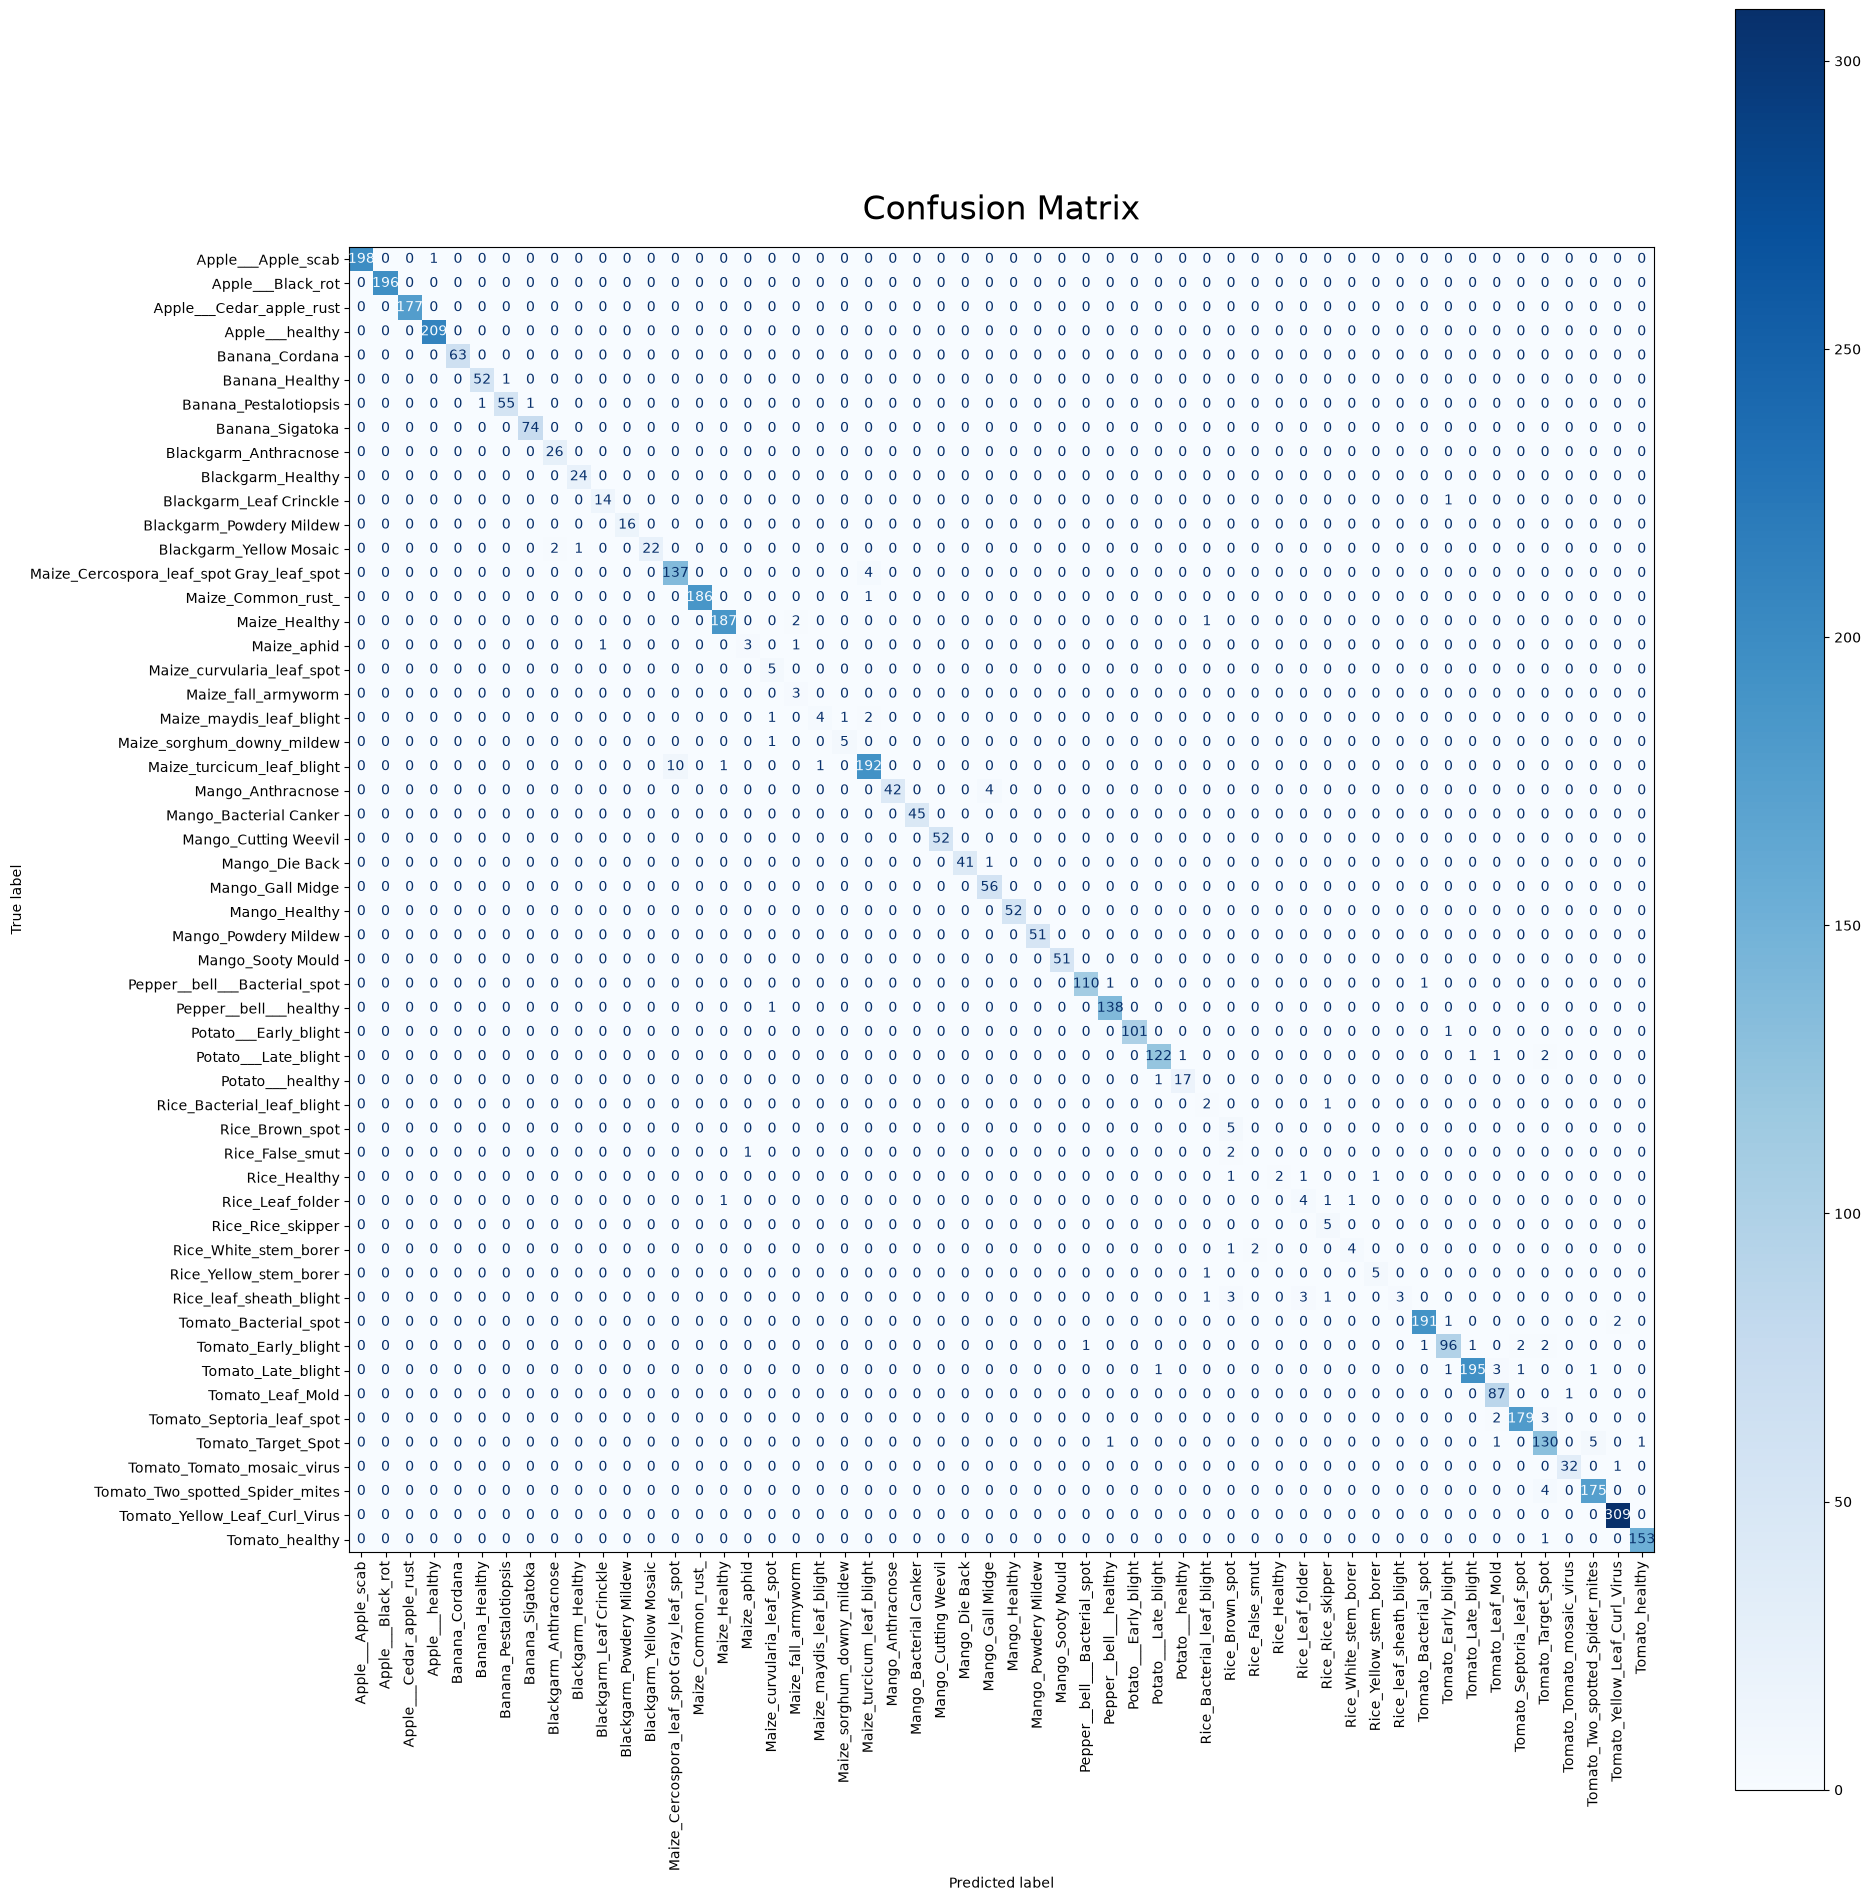

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Class labels
class_names = full_dataset.classes

# Generate confusion matrix
conf_matrix = confusion_matrix(efficientnet_optuna_abels, efficientnet_optuna_predictions)

# Create larger figure
fig, ax = plt.subplots(figsize=(20, 20))

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=class_names
)

disp.plot(
    cmap=plt.cm.Blues,
    xticks_rotation=90,
    ax=ax,
    colorbar=True
)

# Improve readability
plt.title("Confusion Matrix", fontsize=24, pad=20)

# Axis label formatting
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Tight layout prevents overlap
plt.tight_layout()

# Save high-quality image
plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [80]:
comparison_df = pd.DataFrame({
    "Model": [
        "CNN",
        "Regularized CNN",
        "EfficientNet",
        "Optuna EfficientNet"
    ],

    "Train Loss": [
        cnn_train_loss,
        cnn_regularized_train_loss,
        efficientnet_train_loss,
        optuna_train_loss
    ],

    "Validation Loss": [
        cnn_val_loss,
        cnn_regularized_val_loss,
        efficientnet_val_loss,
        optuna_val_loss
    ],

    "Validation Accuracy (%)": [
        cnn_val_acc,
        cnn_regularized_val_acc,
        efficientnet_val_acc,
        optuna_val_acc
    ]
})

comparison_df

,Model,Train Loss,Validation Loss,Validation Accuracy (%)
0,CNN,"[1.117488648901176, 0.42297334044982604, 0.256...","[0.5889738068079149, 0.39170125786110366, 0.39...","[81.05167724388032, 88.10063463281958, 88.1006..."
1,Regularized CNN,"[1.8941787835261223, 1.0063177259100207, 0.808...","[0.9099431820382665, 0.632365229069268, 0.5338...","[71.32819582955575, 79.1704442429737, 84.06618..."
2,EfficientNet,"[1.6687964524124712, 0.47771963893232405, 0.30...","[0.5540455968295674, 0.28486357479341873, 0.20...","[87.98730734360834, 92.8377153218495, 94.10698..."
3,Optuna EfficientNet,0.073628,0.080423,97.5068


In [82]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total   = 0
 
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
 
            outputs          = model(images)
            _, predicted     = torch.max(outputs, 1)
 
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
 
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy

In [84]:
test_model(model_with_efficientNet, test_loader)

Test Accuracy: 97.76%


97.7561196736174

In [86]:
torch.save(
    model_with_efficientNet.state_dict(),
    "saved_image_DetectionModel.pth"
)